<a href="https://colab.research.google.com/github/divyansh212/AI-MODELS-/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'fifa-world-cup-2026-player-performance-dataset' dataset.
Loaded dataset: 54600 rows, 75 cols
Height=height_cm | Weight=weight_kg | Age=age | Position=position
30 performance metrics found

===== HEIGHT vs PERFORMANCE =====
Pearson correlation: -0.078 (p=0.0000)
ANOVA across height groups: F=187.88, p=0.0000
               mean  count
height_group              
<175cm        0.138   9635
175-185cm     0.136  29901
>185cm        0.122  15064


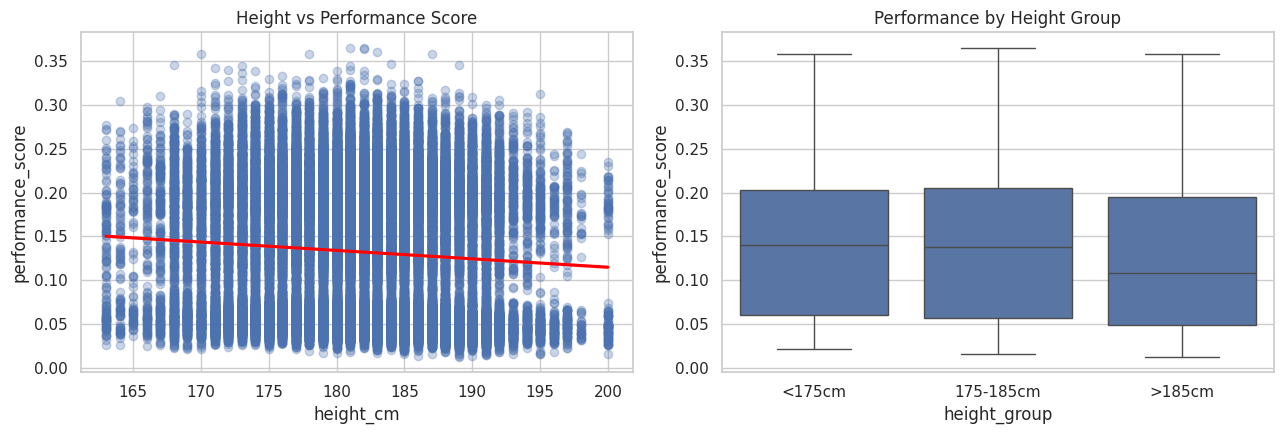


Model features: ['height_cm', 'weight_kg', 'position', 'age']

DL trained 89 epochs in 264.2s

===== MODEL COMPARISON =====
              Model    MAE     R2  Train time (s)  Inference time (s)  Size (MB)
 Random Forest (ML) 0.0685 0.0299          9.5903              0.5026    51.2653
Neural Network (DL) 0.0685 0.0371        264.2316              0.6981     0.1894


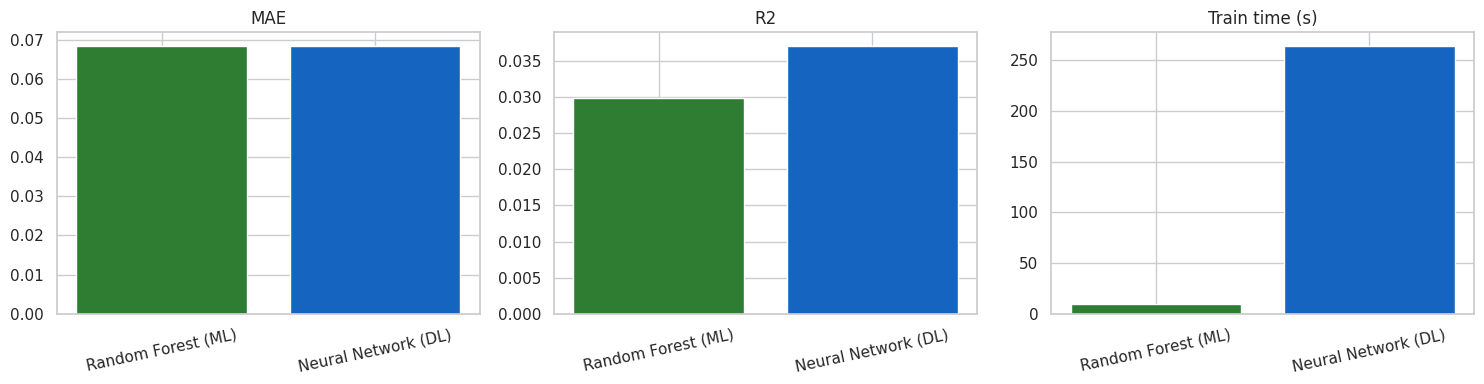

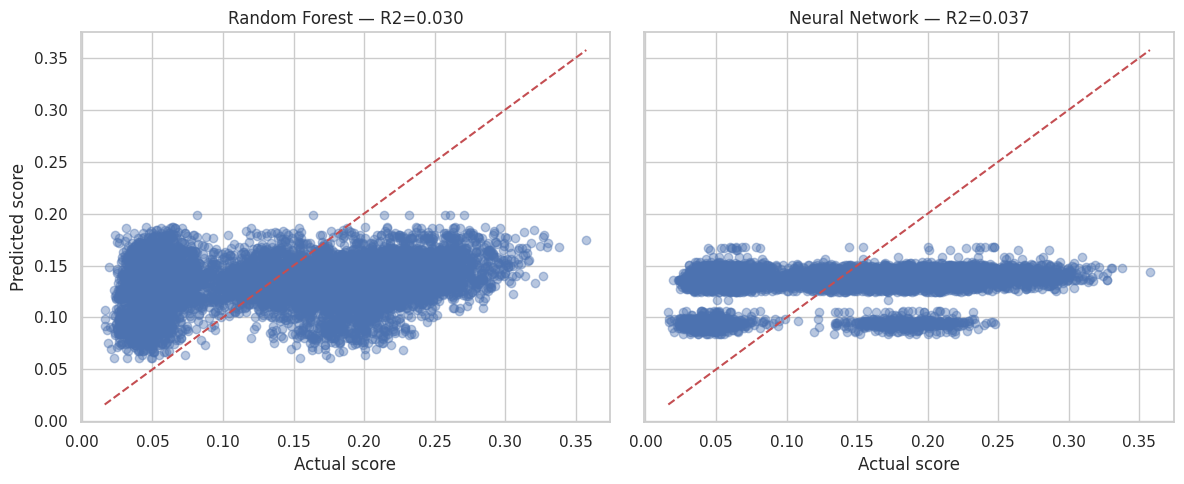


===== VERDICT =====
Best prediction quality (lowest MAE): Neural Network (DL)
Fastest to train: Random Forest (ML)
Height's share of feature importance: 22.1%
If accuracy is close but train time differs a lot, the simpler
model is the more EFFICIENT choice for this tabular problem.


In [1]:
# ================================================================
# FIFA WC 2026: Height vs Performance — Random Forest vs Deep Learning
# Single-cell version. Runtime: ~2-4 min on Colab CPU.
# ================================================================
!pip install -q kagglehub

import kagglehub, os, glob, time, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

# ---------- 1. DOWNLOAD & LOAD ----------
path = kagglehub.dataset_download(
    'rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset')
csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
df = pd.read_csv(max(csv_files, key=os.path.getsize))
print(f'Loaded dataset: {df.shape[0]} rows, {df.shape[1]} cols')

# ---------- 2. DETECT COLUMNS ----------
def find_col(frame, keywords):
    for c in frame.columns:
        if any(k in c.lower() for k in keywords):
            return c
    return None

height_col = find_col(df, ['height'])
weight_col = find_col(df, ['weight'])
age_col    = find_col(df, ['age'])
pos_col    = find_col(df, ['position', 'role'])
assert height_col, f'No height column. Columns: {list(df.columns)}'
print(f'Height={height_col} | Weight={weight_col} | Age={age_col} | Position={pos_col}')

PERF_KEYWORDS = ['goal', 'assist', 'shot', 'pass', 'tackle', 'intercept',
                 'duel', 'save', 'clearance', 'dribble', 'block', 'rating',
                 'minutes', 'key_pass', 'accuracy']
perf_cols = [c for c in df.select_dtypes(include=np.number).columns
             if any(k in c.lower() for k in PERF_KEYWORDS) and c != height_col]
print(f'{len(perf_cols)} performance metrics found')

# ---------- 3. PERFORMANCE SCORE ----------
data = df.copy()
data[height_col] = pd.to_numeric(data[height_col], errors='coerce')
data = data.dropna(subset=[height_col])
data['performance_score'] = MinMaxScaler().fit_transform(
    data[perf_cols].fillna(0)).mean(axis=1)

# ---------- 4. HEIGHT vs PERFORMANCE ANALYSIS ----------
corr, corr_p = stats.pearsonr(data[height_col], data['performance_score'])
data['height_group'] = pd.cut(data[height_col], bins=[0, 175, 185, 250],
                              labels=['<175cm', '175-185cm', '>185cm'])
groups = [g['performance_score'].values
          for _, g in data.groupby('height_group', observed=True) if len(g) > 5]
f_stat, p_val = stats.f_oneway(*groups)

print('\n===== HEIGHT vs PERFORMANCE =====')
print(f'Pearson correlation: {corr:.3f} (p={corr_p:.4f})')
print(f'ANOVA across height groups: F={f_stat:.2f}, p={p_val:.4f}')
print(data.groupby('height_group', observed=True)['performance_score']
          .agg(['mean', 'count']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.regplot(data=data, x=height_col, y='performance_score', ax=axes[0],
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
axes[0].set_title('Height vs Performance Score')
sns.boxplot(data=data, x='height_group', y='performance_score', ax=axes[1])
axes[1].set_title('Performance by Height Group')
plt.tight_layout(); plt.show()

# ---------- 5. FEATURES & PREPROCESSING ----------
feature_cols = [c for c in [height_col, weight_col, pos_col] if c]
if age_col and pd.api.types.is_numeric_dtype(data[age_col]):
    feature_cols.append(age_col)
print('\nModel features:', feature_cols)

X = data[feature_cols]
y = data['performance_score']
num_f = X.select_dtypes(include=np.number).columns.tolist()
cat_f = X.select_dtypes(exclude=np.number).columns.tolist()

prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num_f),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_f)
])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)
if hasattr(X_tr_p, 'toarray'):
    X_tr_p, X_te_p = X_tr_p.toarray(), X_te_p.toarray()
n_features = X_tr_p.shape[1]

# ---------- 6. MACHINE LEARNING MODEL (Random Forest) ----------
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
t0 = time.time(); rf_model.fit(X_tr_p, y_tr); ml_train_time = time.time() - t0
t0 = time.time()
for _ in range(10): rf_pred = rf_model.predict(X_te_p)
ml_infer_time = (time.time() - t0) / 10

# ---------- 7. DEEP LEARNING MODEL (Keras MLP) ----------
dl_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
dl_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                           restore_best_weights=True),
             keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                               patience=7, min_lr=1e-5)]
t0 = time.time()
history = dl_model.fit(X_tr_p, y_tr, validation_split=0.2, epochs=200,
                       batch_size=32, callbacks=callbacks, verbose=0)
dl_train_time = time.time() - t0
t0 = time.time()
for _ in range(10): dl_pred = dl_model.predict(X_te_p, verbose=0).flatten()
dl_infer_time = (time.time() - t0) / 10
print(f'\nDL trained {len(history.history["loss"])} epochs in {dl_train_time:.1f}s')

# ---------- 8. COMPARISON ----------
joblib.dump(rf_model, 'rf.joblib'); dl_model.save('dl.keras')
results = pd.DataFrame({
    'Model': ['Random Forest (ML)', 'Neural Network (DL)'],
    'MAE': [mean_absolute_error(y_te, rf_pred), mean_absolute_error(y_te, dl_pred)],
    'R2':  [r2_score(y_te, rf_pred), r2_score(y_te, dl_pred)],
    'Train time (s)': [ml_train_time, dl_train_time],
    'Inference time (s)': [ml_infer_time, dl_infer_time],
    'Size (MB)': [os.path.getsize('rf.joblib')/1e6, os.path.getsize('dl.keras')/1e6],
})
print('\n===== MODEL COMPARISON =====')
print(results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'R2', 'Train time (s)']):
    ax.bar(results['Model'], results[metric], color=['#2e7d32', '#1565c0'])
    ax.set_title(metric); ax.tick_params(axis='x', rotation=12)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, pred, name in [(axes[0], rf_pred, 'Random Forest'),
                       (axes[1], dl_pred, 'Neural Network')]:
    ax.scatter(y_te, pred, alpha=0.4)
    lims = [float(y_te.min()), float(y_te.max())]
    ax.plot(lims, lims, 'r--')
    ax.set_title(f'{name} — R2={r2_score(y_te, pred):.3f}')
    ax.set_xlabel('Actual score')
axes[0].set_ylabel('Predicted score')
plt.tight_layout(); plt.show()

# Feature importance (height's contribution)
feat_names = prep.get_feature_names_out()
imp = pd.Series(rf_model.feature_importances_, index=feat_names)
height_imp = imp[[i for i in imp.index if 'height' in i.lower()]].sum()

# ---------- 9. VERDICT ----------
wq = results.loc[results['MAE'].idxmin(), 'Model']
ws = results.loc[results['Train time (s)'].idxmin(), 'Model']
print('\n===== VERDICT =====')
print(f'Best prediction quality (lowest MAE): {wq}')
print(f'Fastest to train: {ws}')
print(f"Height's share of feature importance: {height_imp:.1%}")
print('If accuracy is close but train time differs a lot, the simpler')
print('model is the more EFFICIENT choice for this tabular problem.')